# House Price Prediction - Hyperparameter Tuning

## Objective

The objective of this notebook is to improve the performance of the best-performing machine learning model identified during the previous stage.

Rather than relying on the default model configuration, hyperparameter tuning is performed using GridSearchCV and cross-validation to identify the combination of parameters that produces the best predictive performance.

The optimized model will then be evaluated on the testing dataset and compared with the baseline model.

## What are Hyperparameters?

Machine learning models contain parameters that are learned automatically during training, such as the coefficients of a linear regression model.

Hyperparameters, on the other hand, are configuration values defined before training begins. They influence how the model learns from the data and can significantly affect predictive performance.

For example, in a Random Forest model:

- `n_estimators` determines the number of decision trees.
- `max_depth` limits the depth of each tree.
- `min_samples_split` specifies the minimum number of observations required to split an internal node.

Selecting appropriate hyperparameter values can improve model accuracy while reducing overfitting.

In [40]:
import pandas as pd
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

## 1. Load the Dataset

The original dataset is loaded and the same preprocessing steps used throughout the project are applied to ensure consistency.

In [41]:
house_data = pd.read_csv("../data/raw/dataset_2.csv")

house_data[["Area_SqFt", "Rooms"]] = (
    SimpleImputer(strategy="median")
    .fit_transform(
        house_data[["Area_SqFt", "Rooms"]]
    )
)

house_data[["Furnishing"]] = (
    SimpleImputer(strategy="most_frequent")
    .fit_transform(
        house_data[["Furnishing"]]
    )
)

In [42]:
X = house_data.drop("Price", axis=1)

y = house_data["Price"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## 2. Build the Preprocessing Pipeline

The preprocessing pipeline is identical to the one used during model comparison. This guarantees that every model receives the same feature transformations.

In [44]:
numerical_features = [
    "Area_SqFt",
    "Rooms",
    "Build_Year"
]

categorical_features = [
    "Location",
    "Street_Type",
    "Furnishing",
    "Property_Type",
    "Has_Pool"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 3. Create the Machine Learning Pipeline

The preprocessing pipeline is combined with a Random Forest Regressor into a single Scikit-Learn Pipeline.

This approach ensures that preprocessing and model training occur as one unified workflow.

In [45]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

## 4. Define the Hyperparameter Grid

A grid of candidate hyperparameter values is created.

GridSearchCV will evaluate every possible combination using cross-validation and select the model that achieves the best average performance.

In [46]:
param_grid = {

    "model__n_estimators": [100, 200, 300],

    "model__max_depth": [
        None,
        10,
        20,
        30
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ]
}

## 5. Perform Hyperparameter Tuning

GridSearchCV performs an exhaustive search over the defined hyperparameter combinations.

Five-fold cross-validation is used to estimate model performance while reducing the risk of overfitting.

In [47]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

## 6. Best Hyperparameters

After evaluating all candidate models, the combination that achieved the highest average cross-validation score is selected.

In [48]:
print("Best Parameters:")

grid_search.best_params_

Best Parameters:


{'model__max_depth': 20,
 'model__min_samples_split': 2,
 'model__n_estimators': 300}

In [49]:
print("Best Cross-Validation Score:")

grid_search.best_score_

Best Cross-Validation Score:


np.float64(0.856505562537234)

## 7. Evaluate the Optimized Model

The optimized model is evaluated on the testing dataset using the same metrics employed during model comparison.

In [50]:
best_model = grid_search.best_estimator_

predictions = best_model.predict(X_test)

In [51]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = root_mean_squared_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 34147.15
RMSE: 43700.38
R²  : 0.9096


## 8. Save the Trained Model

The optimized model is saved to disk using Joblib.

Saving the trained pipeline allows it to be reused later without repeating the training process, which is essential for deployment.

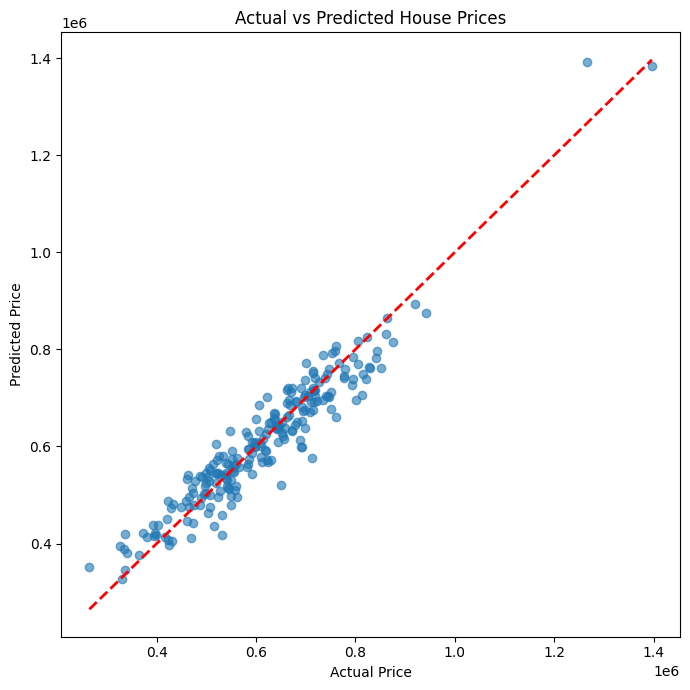

R² Score: 0.910


In [ ]:
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

# Conclusions

Hyperparameter tuning improved the predictive performance of the Random Forest model by identifying a more effective configuration than the default settings.

The optimized model has been saved and is now ready to be integrated into a prediction application.